# T-TEST PAREADO

Supongamos que construimos un primer modelo de Machine Learning para evaluar el precio de una vivienda. Y supongamos que medimos el desempeño de este modelo como:

$$error = |y_{pred}-y|$$

donde $y_{pred}$ es el precio predicho para la vivienda y $y$ es su valor real.

Y supongamos que construimos una versión mejorada de este modelo usando técnicas de escalamiento de los datos.

**Queremos comparar los errores por vivienda antes y después del cambio para determinar si el nuevo modelo funciona mejor o no**

## 1. Desarrollo de la prueba de hipótesis

Se trata de una prueba t pareada porque por cada vivienda tenemos los errores en la predicción **con uno y otro modelo**. 

### 1.1. Paso 1: definir el problema del negocio

> **El nuevo modelo: ¿genera mejores o peores predicciones del precio de las viviendas en comparación con el modelo anterior?**

### 1.2. Paso 2: redactar el problema del negocio como un problema de Ciencia de Datos/Machine Learning

> **¿Existe una diferencia significativa en los errores de predicción antes y después de aplicar técnicas de escalamiento al modelo de Machine Learning?**

### 1.3. Paso 3: definir $H_0$ y $H_1$

Sea:

$$d_i = error_{i_{después}} - error_{i_{antes}}$$

la diferencia en los errores de predicción en el precio de la vivienda $i$ antes y después de implementar la técnica de escalamiento.

Y sea:

$$\bar{x_d} = \frac{\sum_i d_i}{n}$$

el promedio de dichas diferencias.

Entonces:

- $H_0$: no hay diferencias significativas en el promedio de diferencias de errores antes y después: $x_d = 0$
- $H_1$: hay diferencias significativas en el promedio de diferencias de errores antes y después: $x_d \neq 0$

### 1.4. Paso 4: definir $\alpha$

Asumiremos un nivel de significancia $\alpha = 0.05$ (bilateral). Aún no dibujaremos la distribución t pues esta depende de los grados de libertad.

### 1.5. Paso 5: definir la potencia de la prueba ($1-\beta$) y el tamaño de la muestra ($n$)

Seguiremos la misma lógica usada en la lección anterior. Es decir:

1. Definimos el tamaño del efecto esperado
2. Definimos la potencia de la prueba esperada (probabilidad entre 0 y 1)
3. Usamos "TTestPower" de "statsmodels" para calcular el tamaño de las muestras. **Este módulo está especialmente diseñado para pruebas t-test de una muestra o pareadas**

De nuevo, podemos usar TTestPower (el mismo módulo usado para el t-test de una muestra):

In [1]:
from statsmodels.stats.power import TTestPower

# Definir tamaño del efecto, potencia de la prueba, alpha y ratio
d = 0.8
power = 0.9
alpha = 0.05

# Instancia de NormalIndPower
analisis = TTestPower()

# Y cálculo del tamaño de la muestra
n = analisis.solve_power(
    effect_size=d,
    alpha = alpha,
    power=power,
    alternative='two-sided', # larger = unilateral derecho, smaller = unilateral izquierdo, two-sided: bilateral
)
print(f"Tamaño de la muestra: {n}")

Tamaño de la muestra: 18.446225469774834


Es decir que:

> **Necesitamos recolectar al menos 19 muestras pareadas para tener una potencia de la prueba de 0.9 y un tamaño del efecto esperado de 0.8, con un nivel de significancia de 0.05**

### 1.6. Paso 6: recolectar y preparar los datos

Supondremos que ya hemos recolectado los datos. Estos se encuentran en el dataset "errores_prediccion_antes_despues.csv":

In [2]:
import pandas as pd

datos = pd.read_csv('errores_prediccion_antes_despues.csv')
datos

,errores_antes,errores_despues
0,27483.570765,23684.859892
1,24308.678494,21459.411128
2,28238.442691,27119.181951
3,32615.149282,32909.022837
4,23829.233126,21432.786499
...,...,...
995,23594.498536,20454.198059
996,33988.432634,33041.475153
997,28204.214306,28967.963609
998,22144.105051,21470.238979


En este caso hemos recolectado errores de predicción (antes y después) para 1.000 viviendas.

Recordemos que para la prueba pareada no se analizan ni los errores de predicción antes ni después sino la diferencia entre ambos. Así que crearemos la columna "d" que contendrá la diferencia entre los errores:

In [3]:
datos["diferencia"] = datos["errores_despues"]-datos["errores_antes"]
datos

,errores_antes,errores_despues,diferencia
0,27483.570765,23684.859892,-3798.710873
1,24308.678494,21459.411128,-2849.267366
2,28238.442691,27119.181951,-1119.260740
3,32615.149282,32909.022837,293.873555
4,23829.233126,21432.786499,-2396.446627
...,...,...,...
995,23594.498536,20454.198059,-3140.300477
996,33988.432634,33041.475153,-946.957482
997,28204.214306,28967.963609,763.749302
998,22144.105051,21470.238979,-673.866072


Esta columna será la base para la prueba t pareada. Así que calculemos el número de datos y el promedio y la desviación estándar de dicha columna:

In [4]:
import numpy as np

n = len(datos)
xd = np.mean(datos['diferencia'])
sd = np.std(datos['diferencia'])

print('Columna diferencias:')
print(f"\tTamaño de la muestra (n): {n}")
print(f"\tMedia (xd): {xd}")
print(f"\tDesviación estándar (sd): {sd}")


Columna diferencias:
	Tamaño de la muestra (n): 1000
	Media (xd): -1141.6724744983117
	Desviación estándar (sd): 1993.9110505892604


Vemos que la media de las diferencias (después - antes) es negativa, así que al parecer el nuevo modelo tiene menores errores que el modelo anterior. Aunque esto tendremos que verificarlo estadísticamente.

Antes de continuar apliquemos la prueba de Shapiro para verificar la normalidad de la columna "diferencia" (se sugiere complementar esta prueba con gráficos Q-Q):

In [5]:
from scipy.stats import shapiro

W1, p_shapiro = shapiro(datos['diferencia'])
print(f"p: {p_shapiro}")

p: 0.7311929770378104


Y vemos que p>0.05 por lo cual no descartamos la hipótesis nula y concluimos que las diferencias tienen una distribución normal.

### 1.7. Paso 7: aplicar la prueba estadística para obtener el valor p

Al igual que en la lección anterior, sugiero usar el módulo "ttest" de la librería Pingouin para aplicar esta prueba.

En este caso introducimos las columnas después ("x") y antes ("y") y fijamos el parámetro "paired" en verdadero:


In [6]:
from pingouin import ttest

resultados = ttest(
    x = datos['errores_despues'].values,
    y = datos['errores_antes'].values, # El segundo arreglo es usualmente el de referencia
    paired = True, # Prueba t-test pareada
    alternative = 'two-sided', # Queremos saber si existen diferencias entre las muestras pareadas, sin importar la dirección
)
resultados


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-18.097496,999,two-sided,1.555944e-63,"[-1265.47, -1017.88]",0.222383,8.091e+59,1.0


Veamos en detalle la estadística y el valor p:

In [7]:
print(f"Estadística (t, muestras pareadas): {resultados['T'].values[0]}")
print(f"Valor p: {resultados['p-val'].values[0]}")

Estadística (t, muestras pareadas): -18.097496205142296
Valor p: 1.5559435639841368e-63


Y podemos también usar el método gráfico, tomando los grados de libertad del campo "dof" de los resultados y luego dibujando la distribución t correspondiente así como las colas derecha e izquierda y el valor de t correspondiente.

En este caso sí haremos uso de la columna "diferencia":

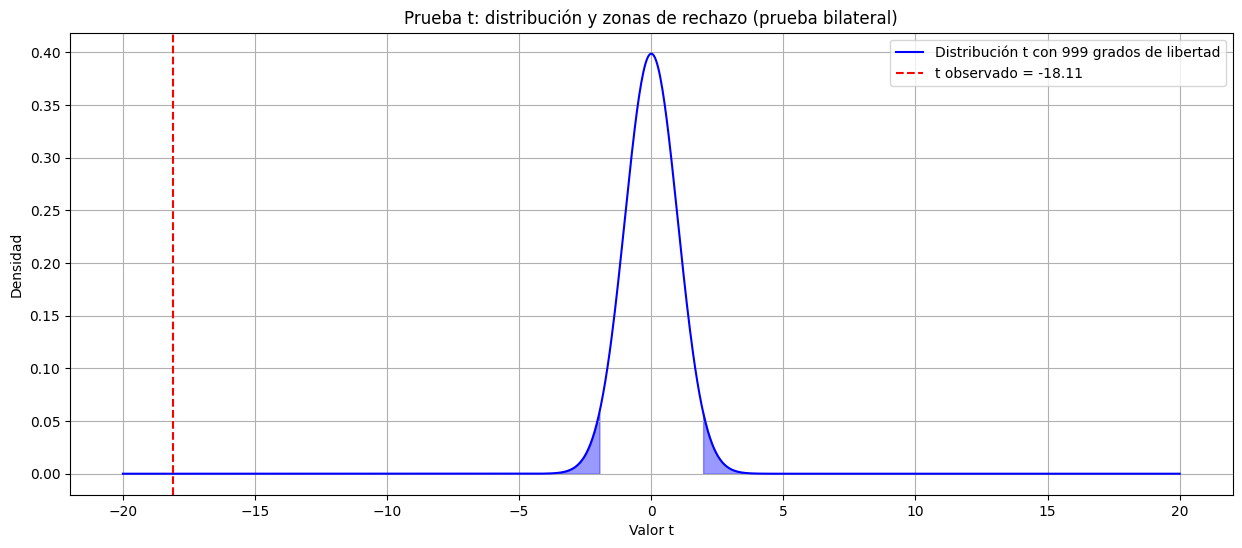

In [8]:
import matplotlib.pyplot as plt
from scipy.stats import t # La distribución t

# Grados de libertad y valor de t
dof = resultados['dof'].values[0] # 1000 - 1 = 999
tval = xd/(sd/np.sqrt(n))
alpha = 0.05

# Distribución t para los "dof" obtenidos
t_vals = np.linspace(-20, 20, 1000)
pdf_vals = t.pdf(t_vals, dof) # Distribución t para "dof" grados de libertad

# Puntos críticos para alfa
t_critico_der = t.ppf(1 - alpha/2, dof) # Zona de rechazo derecha ASUMIENDO DISTRIBUCIÓN CON "dof" GRADOS DE LIBERTAD
t_critico_izq = t.ppf(alpha/2, dof) # Zona de rechazo izquierda

# Graficar la distribución
plt.figure(figsize=(15, 6))
plt.plot(t_vals, pdf_vals, label=f"Distribución t con {int(dof)} grados de libertad", color='blue')

# Zonas de rechazo derecha e izquierda
t_rechazo_der = np.linspace(t_critico_der, 20, 100) # Irá desde t_critico_der hasta 20, 100 datos
t_rechazo_izq = np.linspace(-20, t_critico_izq, 100) # Irá desde -20 hasta t_critico_izq
plt.fill_between(t_rechazo_der, t.pdf(t_rechazo_der, dof), color='blue', alpha=0.4)
plt.fill_between(t_rechazo_izq, t.pdf(t_rechazo_izq, dof), color='blue', alpha=0.4)

# Dibujar estadística t en la distribución anterior
plt.axvline(tval, color='red', linestyle='--', label=f't observado = {tval:.2f}')

# Etiquetas
plt.title('Prueba t: distribución y zonas de rechazo (prueba bilateral)')
plt.xlabel('Valor t')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)

### 1.8. Paso 8: aceptar o rechazar $H_0$

Y con las pruebas anteriores, incluyendo el valor p de $1.55x10^{-63}$ podemos rechazar la hipótesis nula (media de las diferencias igual a cero) y nos inclinamos por $H_1$ (la media de las diferencias es diferente de cero).

Y por tanto:

> Existe una diferencia significativa en los errores de predicción antes y después de aplicar técnicas de escalamiento al modelo de Machine Learning. De hecho, después de aplicar las técnicas el error obtenido en las predicciones es significativamente menor (es decir el segundo modelo genera mejores predicciones)

### 1.9. Paso 9: evaluar el tamaño del efecto y la potencia de la prueba actualizadas

Estos valores ya los obtuvimos previamente con Pingouin:

In [9]:
print(f"Tamaño del efecto actualizado: {resultados['cohen-d'].values[0]}")
print(f"Potencia de la prueba actualizada: {resultados['power'].values[0]}")

Tamaño del efecto actualizado: 0.22238300883198206
Potencia de la prueba actualizada: 0.9999997964762224


Según la escala de Cohen:

- 0.2 es un efecto pequeño
- 0.5 es un efecto mediano
- 0.8 es un efecto grande

Lo anterior nos dice que a pesar de que se observó un efecto (p << 0.05) la magnitud de esa diferencia entre las medias es modesta (porque el tamaño del efecto es pequeño: 0.22).

Mientras que la probabilidad de detectar una diferencia real es de prácticamente el 100% (potencia de 0.99999...)